# Naive Bayes

The course colab classified newsgroup posts with TF-IDF + multinomial naive Bayes. This version adds the
theory, a small example worked out by hand so the numbers can be checked, and Gaussian naive Bayes for
numeric features.

1. Bayes' rule and the "naive" assumption
2. multinomial NB on word counts, by hand and with sklearn
3. TF-IDF
4. text classification on 20 newsgroups
5. Gaussian NB on numeric data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups, load_iris
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.pipeline import make_pipeline

## The idea

Bayes' rule for class $y$ and features $\mathbf{x} = (x_1, \dots, x_m)$:

$$P(y \mid \mathbf{x}) = \frac{P(y) \, P(\mathbf{x} \mid y)}{P(\mathbf{x})}$$

$P(\mathbf{x} \mid y)$ over all features jointly is impossible to estimate with realistic amounts of data.
The **naive** assumption is that features are independent given the class, so it factorises:

$$P(y \mid \mathbf{x}) \propto P(y) \prod_{j=1}^{m} P(x_j \mid y)$$

Each $P(x_j \mid y)$ is easy to estimate from counts. Predict the class with the largest value. The
denominator is the same for every class, so it can be ignored.

The independence assumption is almost never true (in text, "machine" and "learning" are obviously
related), but the classifier often works well anyway, because it only needs to get the *ranking* of
classes right, not the exact probabilities. It's fast, needs little data, and is a standard baseline for
text.

## A tiny example by hand

Four training "documents", two classes:

In [2]:
docs = ["rocket launch orbit", "orbit moon rocket rocket", "pixel image render", "render pixel shader image"]
labels = ["space", "space", "graphics", "graphics"]

cv = CountVectorizer()
counts = cv.fit_transform(docs)
pd.DataFrame(counts.toarray(), columns=cv.get_feature_names_out(), index=labels)

,image,launch,moon,orbit,pixel,render,rocket,shader
space,0,1,0,1,0,0,1,0
space,0,0,1,1,0,0,2,0
graphics,1,0,0,0,1,1,0,0
graphics,1,0,0,0,1,1,0,1


**Multinomial NB** models each class as a distribution over words. With Laplace smoothing ($\alpha = 1$,
add one to every count so unseen words don't get probability 0):

$$P(w \mid y) = \frac{\text{count}(w, y) + \alpha}{\text{total words in } y + \alpha \cdot |V|}$$

Vocabulary size $|V| = 8$. The "space" documents have 7 words in total: "rocket" appears 3 times, "pixel"
0 times. So

* $P(\text{rocket} \mid \text{space}) = (3 + 1) / (7 + 8) = 0.267$
* $P(\text{pixel} \mid \text{space}) = (0 + 1) / (7 + 8) = 0.067$

For a new document "rocket pixel", with equal priors (2 documents each):

In [3]:
vocab = list(cv.get_feature_names_out())
X_counts = counts.toarray()
alpha = 1

def word_prob(word, cls):
    rows = [i for i, l in enumerate(labels) if l == cls]
    class_counts = X_counts[rows].sum(axis=0)
    return (class_counts[vocab.index(word)] + alpha) / (class_counts.sum() + alpha * len(vocab))

new_doc = ["rocket", "pixel"]
for cls in ["space", "graphics"]:
    score = 0.5 * np.prod([word_prob(w, cls) for w in new_doc])
    print(f"{cls:9s} P(y) * prod P(w|y) = {score:.5f}")

space     P(y) * prod P(w|y) = 0.00889
graphics  P(y) * prod P(w|y) = 0.00667


Normalised so they add to 1:

In [4]:
s_space = 0.5 * word_prob("rocket", "space") * word_prob("pixel", "space")
s_graph = 0.5 * word_prob("rocket", "graphics") * word_prob("pixel", "graphics")
print(f"by hand:  space {s_space / (s_space + s_graph):.4f}   graphics {s_graph / (s_space + s_graph):.4f}")

mnb = MultinomialNB(alpha=1).fit(counts, labels)
proba = mnb.predict_proba(cv.transform(["rocket pixel"]))[0]
print(f"sklearn:  space {proba[list(mnb.classes_).index('space')]:.4f}   graphics {proba[list(mnb.classes_).index('graphics')]:.4f}")

by hand:  space 0.5714   graphics 0.4286
sklearn:  space 0.5714   graphics 0.4286


Same numbers. "rocket" appears three times in space docs, "pixel" twice in graphics docs, so space wins
by a small margin. In practice sklearn works with log-probabilities (`feature_log_prob_`), adding instead
of multiplying, since multiplying thousands of small probabilities underflows to 0.

## TF-IDF

Raw counts give common words like "the" or "subject" a lot of weight even though they say nothing about
the topic. **TF-IDF** scales each word's count in a document by how rare the word is across all documents:

$$\text{tfidf}(w, d) = \text{tf}(w, d) \times \text{idf}(w), \qquad \text{idf}(w) = \ln\frac{1 + n}{1 + \text{df}(w)} + 1$$

where df is the number of documents containing the word. sklearn then normalises each document vector to
length 1.

In [5]:
corpus = ["the rocket reached orbit", "the image has a pixel error", "the rocket image"]
tfidf = TfidfVectorizer()
pd.DataFrame(tfidf.fit_transform(corpus).toarray(), columns=tfidf.get_feature_names_out()).round(2)

,error,has,image,orbit,pixel,reached,rocket,the
0,0.0,0.0,0.00,0.58,0.0,0.58,0.44,0.35
1,0.5,0.5,0.38,0.00,0.5,0.00,0.00,0.30
2,0.0,0.0,0.62,0.00,0.0,0.00,0.62,0.48


"the" is in every document, so it gets the lowest weight in each row. "orbit" and "pixel" only appear once
and get the highest.

(Strictly, multinomial NB is defined for counts, but TF-IDF values work well with it in practice, and
that's the standard pipeline.)

## 20 newsgroups

About 18,000 posts from 20 Usenet newsgroups. `fetch_20newsgroups` downloads it the first time.

The outputs in this section are from my Colab run: the download source isn't reachable from where I
rebuilt the notebooks.

In [6]:
data = fetch_20newsgroups()
data.target.shape

(11314,)

In [7]:
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

Four of the categories, with the standard train/test split (by date, so the test posts are later than the
training ones):

In [8]:
categories = ['talk.religion.misc', 'soc.religion.christian', 'sci.space', 'comp.graphics']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

In [9]:
print(train.data[6])

From: will@rins.ryukoku.ac.jp (William Reiken)
Subject: Re: nuclear waste
Organization: Ryukoku Univ., Seta, Japan
Lines: 4


	Thanks for the Update.

							Will...



Raw text with email headers. `TfidfVectorizer` turns each post into a sparse vector with one entry per word
in the vocabulary (tens of thousands of columns), and the pipeline passes that to the classifier.

In [10]:
model = make_pipeline(TfidfVectorizer(), MultinomialNB())
model.fit(train.data, train.target)

Pipeline(steps=[('tfidfvectorizer', TfidfVectorizer()),
                ('multinomialnb', MultinomialNB())])

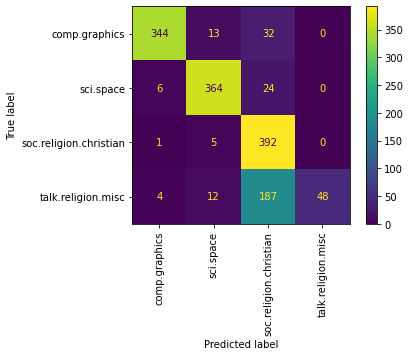

In [11]:
ConfusionMatrixDisplay.from_estimator(model, test.data, test.target,
                                      display_labels=test.target_names, xticks_rotation='vertical')
plt.show()

* `comp.graphics` and `sci.space` are separated well by such a simple model.
* The two religion groups get mixed up, and it's very one-sided: 187 of the 251 `talk.religion.misc` posts
  are predicted as `soc.religion.christian`, and only 48 are classified correctly. It's the smallest class,
  so its prior is lowest, and the two groups use a lot of the same vocabulary, so anything ambiguous ends
  up in the bigger one. Overall accuracy is about 75%, but recall for that class is under 20%.

Classifying new text:

In [12]:
def predict_category(s, train=train, model=model):
    pred = model.predict([s])
    return train.target_names[pred[0]]

In [13]:
predict_category('Exoplanet habitat')

'sci.space'

In [14]:
predict_category('discussing christianity crusade')

'soc.religion.christian'

In [15]:
predict_category('determining the screen resolution')

'comp.graphics'

Things worth trying on this data (not run here):

* `TfidfVectorizer(stop_words='english', sublinear_tf=True)` and tuning `MultinomialNB(alpha=...)` with a grid search
* `fetch_20newsgroups(..., remove=('headers', 'footers', 'quotes'))`. The headers leak information (email
  addresses, organisation names) that make the task easier than it really is
* `ComplementNB`, a variant designed for imbalanced text classes

## Gaussian naive Bayes

For continuous features, `GaussianNB` assumes each feature follows a normal distribution within each class.
Training just means computing a mean and variance per feature per class.

In [16]:
X, y = load_iris(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

gnb = GaussianNB().fit(X_train, y_train)
print(f"test accuracy: {gnb.score(X_test, y_test):.3f}")
print(f"5-fold CV accuracy: {cross_val_score(GaussianNB(), X, y, cv=5).mean():.3f}")

test accuracy: 0.978
5-fold CV accuracy: 0.953


In [17]:
pd.DataFrame(gnb.theta_, columns=X.columns, index=load_iris().target_names).round(2)   # per-class means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,5.03,3.42,1.43,0.25
versicolor,5.89,2.73,4.23,1.31
virginica,6.68,2.97,5.61,2.04


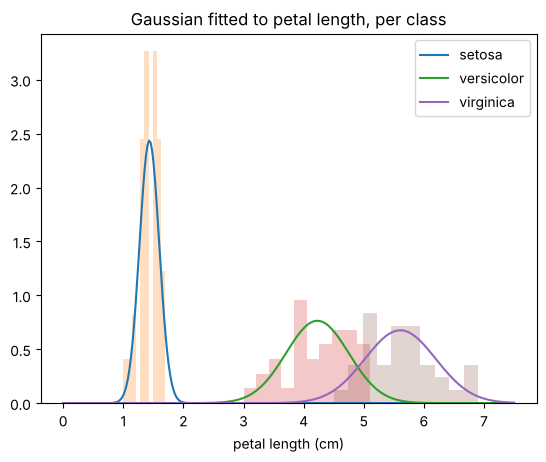

In [18]:
x = np.linspace(0, 7.5, 300)
for k, name in enumerate(load_iris().target_names):
    mu, var = gnb.theta_[k, 2], gnb.var_[k, 2]
    plt.plot(x, np.exp(-(x - mu) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var), label=name)
    plt.hist(X_train.loc[y_train == k, 'petal length (cm)'], density=True, alpha=0.25, bins=10)
plt.xlabel('petal length (cm)'); plt.legend()
plt.title('Gaussian fitted to petal length, per class')
plt.show()

Petal length alone separates setosa completely. Versicolor and virginica overlap a little, and the other
features help resolve that.

## Which naive Bayes?

| class | features | typical use |
|---|---|---|
| `MultinomialNB` | counts / frequencies | text with word counts or TF-IDF |
| `ComplementNB` | same | text with imbalanced classes |
| `BernoulliNB` | binary (word present or not) | short texts |
| `GaussianNB` | continuous | numeric features |
| `CategoricalNB` | categorical | encoded categories |